# Raw Copula Innovations — Monte Carlo Simulation

Stage 3, step 1. Draws the correlated stochastic shocks that every scenario in
the study shares, before any AR/ARMA propagation or deterministic mean
reconstruction.

## Objective
Simulate `N_SIM` paths of daily innovations `(eps_CR, eps_KT, eps_temp)` over
2026-2050 from the fitted 3-D Student-t copula, inverting each variable through
its own marginal so the draws land on the residual scale the reconstruction
notebook expects.

These innovations are **scenario-agnostic**: they carry no penetration or
temperature assumption. Drawing them once and reusing the file across all
scenarios is what makes the scenario comparison a common-random-numbers
experiment, in which the difference between two scenarios is a pure
assumption effect rather than Monte Carlo noise.

## Pipeline Position

| Inputs | This notebook | Outputs |
|---|---|---|
| `Code/Models/Copula/copula_params.pkl` (nu, corr, Cholesky) | Draw t-copula scores -> uniforms -> invert per-variable marginals | `Data/Simulated/mc_innovations.parquet` |
| `Code/Models/Copula/marginal_params.pkl` (KT mixture, temperature t) | | `Data/Simulated/mc_innovations_metadata.pkl` |
| `Code/Models/Capture rate/cr_ar_params.pkl` (skewed-t shape) | | |

## Decision Log

| # | Decision | Alternatives | Rationale | Impact |
|---|---|---|---|---|
| D1 | `scale_unit_cr = 1.0` — the capture-rate innovations are **not** rescaled | Multiply by `sqrt(nu/(nu-2))` | `eps_cr` is consumed downstream as the GARCH standardised residual `z_t` in `u_t = z_t * sqrt(sigma2_t)`, which requires `E[z_t^2] = 1`. The `arch` skew-t quantile function already returns zero-mean, unit-variance draws | A previous `sqrt(nu/(nu-2)) = 1.377` de-standardised the innovations to `E[z^2] = 1.89` and pushed GARCH persistence to 1.052, i.e. non-stationary. Asserted below |
| D2 | KT marginal is a per-month 2-component Gaussian mixture, with **no** `sigma_kt` multiply | Single Gaussian scaled by `sigma_kt` | The KT innovations are bimodal (cloudy/sunny regimes) with a mix that shifts through the year, and the mixture carries a month-specific mean offset the annual harmonic does not absorb | A Gaussian margin drops both. Applying `sigma_kt` on top of the mixture would inflate its standard deviation by roughly 2.35x |
| D3 | Mixture quantiles by tabulated grid interpolation, not bisection | 60-iteration bisection per batch | Bisection costs about 106 s per batch against 0.5 s for a tabulated inverse, at an accuracy of roughly 1e-7 — below the float32 storage resolution, so the stored draws are indistinguishable from exact inversion | Grid bracket `[-14, 11]` clears the 1e-6 and 1-1e-6 quantiles of all twelve months by about three orders of magnitude; asserted per month |
| D4 | One `default_rng(RANDOM_SEED)` created with the configuration, used for both the draw and the validation sample, in a single merged cell | `np.random.seed` plus the legacy global functions, across separate cells | Splitting the seed, the pre-allocation and the sampling loop across cells would let a partial re-run — the natural thing to do after a tweak — silently advance the global stream and change the draw | The draw is reproducible cell-by-cell, and the validation subsample is reproducible too |
| D5 | All three innovation arrays stored as float32 | float64 for `eps_cr` | float32 carries about 7 significant digits, orders of magnitude finer than the modelling error in any of these marginals | `eps_cr` alone was float64 with a no-op `astype`, costing roughly 180 MB of RAM and a large share of the output file |
| D6 | Validation gates on **statistics**, not p-values, for the distributional checks | Assert KS p > 0.05 | At roughly 4.6M draws a KS test rejects on differences far below the grid-interpolation error, so a p-value gate would fail on a correct run | The gate is on the KS statistic, whose sampling noise at this n is about 4e-4, against a threshold of 1e-2 |

## Setup

In [1]:
import pickle
import time
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq
from arch.univariate.distribution import SkewStudent
from scipy import stats
from scipy.stats import t as t_dist, norm

sys.path.append(str(Path("..").resolve()))
from model_utils import find_project_root

warnings.filterwarnings("ignore")

In [2]:
# -- paths ---------------------------------------------------------------------
ROOT          = find_project_root()
copula_path   = ROOT / "Code" / "Models" / "Copula"
models_path   = ROOT / "Code" / "Models"
data_modelled = ROOT / "Data" / "Modelled"
data_sim      = ROOT / "Data" / "Simulated"
data_sim.mkdir(parents=True, exist_ok=True)


In [3]:
# -- simulation constants ------------------------------------------------------
N_SIM       = 5000              # number of Monte Carlo paths
START_DATE  = "2026-01-01"
END_DATE    = "2050-12-31"
RANDOM_SEED = 42

# variable order -- must match the copula estimation order
VAR_LABELS = ["CR", "KT", "Temp"]
VAR_COLS   = ["eps_cr", "eps_kt", "eps_temp"]

# D4: one generator for the whole notebook -- the draw below and the validation
# subsample both take from it, so every number in this notebook is reproducible
# from RANDOM_SEED alone. A module-level np.random.seed() would leave the draw
# dependent on how many cells had been run before it.
rng = np.random.default_rng(RANDOM_SEED)

print("-- Configuration -----------------------------------------------")
print(f"  N_SIM      : {N_SIM:,} paths")
print(f"  Horizon    : {START_DATE} -> {END_DATE}")
print(f"  Random seed: {RANDOM_SEED}")
print(f"  Variables  : {VAR_LABELS}")
print(f"  Output     : {data_sim}")

-- Configuration -----------------------------------------------
  N_SIM      : 5,000 paths
  Horizon    : 2026-01-01 -> 2050-12-31
  Random seed: 42
  Variables  : ['CR', 'KT', 'Temp']
  Output     : C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Data\Simulated


### Copula and marginal parameters

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 0.2: Load copula parameters ────────────────────────────")

# ── copula ────────────────────────────────────────────────────────────────────
with open(copula_path / "copula_params.pkl", "rb") as f:
    copula_params = pickle.load(f)
 
nu_copula   = int(copula_params["nu"])
corr_matrix = np.array(copula_params["corr_matrix"])
chol_matrix = np.array(copula_params["chol_matrix"])
 
print(f"  Copula     : {copula_params['copula_type'].upper()}  ν={nu_copula}")
print(f"  Variables  : {copula_params['variables']}")
print(f"  n_obs fit  : {copula_params['n_obs']}")


── Step 0.2: Load copula parameters ────────────────────────────
  Copula     : T  ν=17
  Variables  : ['U_cr', 'U_kt', 'U_temp']
  n_obs fit  : 4018


In [5]:
# ── marginal scale parameters ─────────────────────────────────────────────────
with open(models_path / "Capture rate" / "cr_ar_params.pkl", "rb") as f:
    cr_params = pickle.load(f)

nu_g         = float(cr_params["nu_g"])
eta_g        = float(cr_params["eta_g"])   # skewness parameter

# D1: CR scale — MUST be 1.0.
#   eps_cr feeds the GARCH recursion as z_t in  u_t = z_t · sqrt(sigma2_t),
#   which requires E[z_t²] = 1.  arch's SkewStudent.ppf already returns
#   zero-mean, unit-variance Hansen skew-t quantiles (verified: mean 0.0005,
#   std 0.9995), so NO rescaling is applied here.
#   The rejected alternative, sqrt(nu/(nu-2)) = 1.37722, de-standardises the
#   innovations to E[z²] = 1.893 and pushes the GARCH persistence to
#   alpha·E[z²] + beta = 1.052 > 1 (non-stationary).  See the stationarity
#   assertion in the reconstruction notebooks.
scale_unit_cr = 1.0

print(f"  CR marginal  : skewed-t(ν={nu_g:.2f}, η={eta_g:+.4f})  "
      f"scale_unit={scale_unit_cr:.5f}  (already unit-variance from arch)")

# load all remaining marginals from covariance notebook output
with open(copula_path / "marginal_params.pkl", "rb") as f:
    marginal_params = pickle.load(f)

# D2: KT is a 2-component Gaussian mixture per calendar month, NOT a
# single Gaussian scaled by sigma_kt.
# Written by the covariance notebook, which in turn loads it from
# Code/Models/GHI - KT/ghi_mixture_params.pkl. The KT innovations are bimodal
# (cloudy/sunny regimes) with a mix that shifts through the year, and the
# mixture also carries a month-specific mean offset that the single annual
# harmonic in Y_bar does not absorb. A Gaussian marginal drops both.
kt_mix   = marginal_params["kt_mixture_params"]
sigma_kt = float(marginal_params["sigma_kt"])   # legacy, reported only
nu_kt    = int(marginal_params["nu_kt"])        # legacy flag, unused
_n_two   = sum(1 for m in range(1, 13) if kt_mix[m]["bic_1"] - kt_mix[m]["bic_2"] > 0)
print(f"  KT marginal  : GMM-2 per calendar month  "
      f"({_n_two}/12 months prefer 2 comps by BIC)")


def mix_cdf(eps, months, mixture_params):
    """Mixture CDF of the KT innovations, evaluated per calendar month.

    Mirrors mix_cdf() in 06_copula.ipynb — the forward transform
    whose inverse is built below. Used by the PIT back-check in Step 2."""
    eps    = np.asarray(eps, dtype=float)
    months = np.asarray(months)
    out    = np.empty_like(eps)
    for m in range(1, 13):
        idx = (months == m)
        if not idx.any():
            continue
        mp = mixture_params[m]
        out[idx] = (mp["weights"][0] * norm.cdf(eps[idx], mp["means"][0], mp["stds"][0]) +
                    mp["weights"][1] * norm.cdf(eps[idx], mp["means"][1], mp["stds"][1]))
    return out


# D3: mixture quantiles by tabulated grid interpolation, not bisection.
# The mixture has no closed-form quantile function. Bisection works but costs
# ~106 s per batch (60 iterations x 2 normal CDFs over 4.6M elements); tabulating
# the CDF once per month and interpolating costs ~0.5 s per batch and is accurate
# to ~1e-7 — below the float32 storage resolution, so the stored draws are
# indistinguishable from exact inversion.
#
# Bracket: the u = 1e-6 and u = 1-1e-6 quantiles across all 12 months span
# [-11.47, +8.57], so [-14, +11] clears the clip on both tails by ~3 orders of
# magnitude. The `keep` trim is REQUIRED, not defensive: 1-F(e) underflows to
# exactly 0.0 in float64 in the far tail, which would leave a flat (non-invertible)
# plateau in the interpolation table.
MIX_LO, MIX_HI, MIX_N = -14.0, 11.0, 50001
_eps_grid = np.linspace(MIX_LO, MIX_HI, MIX_N)
MIX_EPS, MIX_CDF = [], []          # list index 0..11  ==  month 1..12
for _m in range(1, 13):
    _w  = np.asarray(kt_mix[_m]["weights"])
    _mu = np.asarray(kt_mix[_m]["means"])
    _sd = np.asarray(kt_mix[_m]["stds"])
    _c  = (_w[0] * norm.cdf(_eps_grid, _mu[0], _sd[0]) +
           _w[1] * norm.cdf(_eps_grid, _mu[1], _sd[1]))
    _keep = (_c > 1e-12) & (_c < 1 - 1e-12)
    assert np.all(np.diff(_c[_keep]) > 0), \
        f"STOP — month {_m} mixture CDF is not strictly increasing on the grid"
    assert _c[_keep][0] < 1e-6 and _c[_keep][-1] > 1 - 1e-6, \
        f"STOP — month {_m} grid bracket [{MIX_LO}, {MIX_HI}] is too narrow"
    MIX_EPS.append(_eps_grid[_keep])
    MIX_CDF.append(_c[_keep])
print(f"                 inverse-CDF grid: {MIX_N:,} nodes on "
      f"[{MIX_LO:.0f}, {MIX_HI:.0f}] per month ✓")

# Temp: t(ν_temp)
# scale_temp standardises the raw t draw so that std ≈ sigma_temp ≈ 1.0;
# the reconstruction notebook then rescales to the fitted innovation sd.
nu_temp    = float(marginal_params["nu_temp"])
scale_temp = float(marginal_params["scale_temp"])
sigma_temp = float(marginal_params["sigma_temp"])  # raw std for reference
print(f"  Temp marginal: t(ν={nu_temp:.2f})  "
      f"scale_t={scale_temp:.5f}  σ_raw={sigma_temp:.5f}")


# ── scale array — one entry per copula variable in order [CR, KT, Temp] ───────
# used only for display and the positivity assert — Step 1 uses individual
# variables. The KT entry is the pooled mixture sd, computed in Step 0.3 once
# the calendar (and hence the month weighting) is known.
scales = np.array([scale_unit_cr, np.nan, scale_temp])
print(f"\n  Scale array [CR, KT, Temp]: [{scale_unit_cr:.5f}, "
      f"<set in Step 0.3>, {scale_temp:.5f}]")

  CR marginal  : skewed-t(ν=4.15, η=-0.1003)  scale_unit=1.00000  (already unit-variance from arch)
  KT marginal  : GMM-2 per calendar month  (12/12 months prefer 2 comps by BIC)


                 inverse-CDF grid: 50,001 nodes on [-14, 11] per month ✓
  Temp marginal: t(ν=7.74)  scale_t=0.86741  σ_raw=1.00734

  Scale array [CR, KT, Temp]: [1.00000, <set in Step 0.3>, 0.86741]


In [6]:
# verify Cholesky reconstruction
recon_err = np.max(np.abs(chol_matrix @ chol_matrix.T - corr_matrix))
print(f"\n  Reconstruction error: {recon_err:.2e}  "
      f"{'✓' if recon_err < 1e-10 else '✗ check chol_matrix'}")


  Reconstruction error: 1.11e-16  ✓


### Simulation calendar

In [7]:
# STEP 0.3 — Build simulation calendar
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 0.3: Simulation calendar ───────────────────────────────")
 
dates_sim = pd.date_range(start=START_DATE, end=END_DATE, freq="D")
N_DAYS    = len(dates_sim)
 
df_calendar = pd.DataFrame({
    "date":        dates_sim,
    "year":        dates_sim.year,
    "month":       dates_sim.month,
    "day":         dates_sim.day,
    "doy":         dates_sim.dayofyear,
    "weekday":     dates_sim.weekday,
    "decimal_year":(dates_sim.year + (dates_sim.dayofyear - 1) / 365.0),
    "t_year":      (dates_sim.dayofyear - 1) / 365.0,
})
 
print(f"  N_DAYS     : {N_DAYS:,}  ({N_DAYS/365.25:.1f} years)")
print(f"  Start      : {dates_sim[0].date()}")
print(f"  End        : {dates_sim[-1].date()}")
print(f"  Total obs  : {N_SIM * N_DAYS:,}  (N_SIM × N_DAYS)")
 
# ── KT mixture: month masks and pooled moments ───────────────────────────────
# The day axis of df_calendar is aligned with U_corr[:, :, 1] in the batch loop,
# so a (N_DAYS,) month mask broadcasts straight across all paths in a batch.
month_idx0  = df_calendar["month"].to_numpy() - 1
MONTH_MASKS = [month_idx0 == i for i in range(12)]

# Pooled mean/variance of eps_kt under the monthly mixture, by the law of total
# variance over the ACTUAL month frequencies of this calendar (months are not
# equally weighted: 31- vs 28-day months, leap years). These are the targets the
# Step 2 validator checks against — the old target, sigma_kt, is the sd of a
# single Gaussian and is 0.36% low.
_p_month = df_calendar["month"].value_counts().sort_index().to_numpy() / N_DAYS
_E_month = np.array([float(np.asarray(kt_mix[m]["weights"]) @
                           np.asarray(kt_mix[m]["means"]))
                     for m in range(1, 13)])
_V_month = np.array([float(np.asarray(kt_mix[m]["weights"]) @
                           (np.asarray(kt_mix[m]["stds"]) ** 2 +
                            np.asarray(kt_mix[m]["means"]) ** 2)) - _E_month[m - 1] ** 2
                     for m in range(1, 13)])
mu_kt_pool  = float(_p_month @ _E_month)
var_kt_pool = float(_p_month @ _V_month +
                    _p_month @ (_E_month - mu_kt_pool) ** 2)
std_kt_pool = float(np.sqrt(var_kt_pool))
scales[1]   = std_kt_pool          # filled in here; see the marginal cell

print(f"  KT mixture : pooled mean={mu_kt_pool:+.5f}  std={std_kt_pool:.5f}  "
      f"(legacy sigma_kt={sigma_kt:.5f})")
print(f"               monthly E[eps] in "
      f"[{_E_month.min():+.3f}, {_E_month.max():+.3f}] — seasonal offset the "
      f"Gaussian margin used to drop")

est_size_mb = N_SIM * N_DAYS * 3 * 4 / 1e6
print(f"  Est. size  : ~{est_size_mb:.0f} MB uncompressed "
      f"(parquet will be ~{est_size_mb*0.3:.0f} MB)")


── Step 0.3: Simulation calendar ───────────────────────────────
  N_DAYS     : 9,131  (25.0 years)
  Start      : 2026-01-01
  End        : 2050-12-31
  Total obs  : 45,655,000  (N_SIM × N_DAYS)
  KT mixture : pooled mean=+0.00080  std=2.34551  (legacy sigma_kt=2.34237)
               monthly E[eps] in [-0.209, +0.332] — seasonal offset the Gaussian margin used to drop
  Est. size  : ~548 MB uncompressed (parquet will be ~164 MB)


### Parameter validation

In [8]:
# STEP 0.4 — Validate copula parameters before simulation
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 0.4: Parameter validation ──────────────────────────────")
 
# check correlation matrix is positive definite
eigenvalues = np.linalg.eigvalsh(corr_matrix)
is_pd = np.all(eigenvalues > 0)
print(f"  Eigenvalues: {np.round(eigenvalues, 4)}")
print(f"  Positive definite: {'✓' if is_pd else '✗ STOP — matrix not PD'}")
 
# check Cholesky is lower triangular
is_lower = np.allclose(chol_matrix, np.tril(chol_matrix))
print(f"  Lower triangular : {'✓' if is_lower else '✗ STOP — not lower triangular'}")
 
# check scales are positive
assert np.all(scales > 0), "STOP — scale parameters must be positive"
print(f"  Scale params > 0 : ✓  {scales}")
 
# check ν
assert nu_copula > 2, "STOP — copula ν must be > 2"
print(f"  Copula ν = {nu_copula} > 2: ✓")
 
if not (is_pd and is_lower):
    raise ValueError("Copula parameters failed validation. "
                     "Re-run covariance notebook.")
 
print(f"\n  All checks passed — proceeding to simulation")


── Step 0.4: Parameter validation ──────────────────────────────
  Eigenvalues: [0.6423 0.9287 1.429 ]
  Positive definite: ✓
  Lower triangular : ✓
  Scale params > 0 : ✓  [1.         2.3455115  0.86741485]
  Copula ν = 17 > 2: ✓

  All checks passed — proceeding to simulation


## Monte Carlo Draw

Seed, pre-allocation and sampling loop are deliberately one cell (D4): splitting
them let a partial re-run silently change the draw.

In [9]:
print("-- Monte Carlo simulation --------------------------------------")
print(f"  Drawing {N_SIM:,} paths x {N_DAYS:,} days = "
      f"{N_SIM*N_DAYS:,} observations per variable...")

t_start = time.time()

# pre-allocate output arrays -- shape (N_SIM, N_DAYS) per variable.
# D5: all three float32. eps_cr was float64 for no benefit -- the marginal is
# fitted to three significant figures, and the file is written float32 anyway.
eps_cr_all   = np.empty((N_SIM, N_DAYS), dtype=np.float32)
eps_kt_all   = np.empty((N_SIM, N_DAYS), dtype=np.float32)
eps_temp_all = np.empty((N_SIM, N_DAYS), dtype=np.float32)

BATCH_SIZE = 500   # paths per batch
n_batches  = int(np.ceil(N_SIM / BATCH_SIZE))

_skewt      = SkewStudent()
_skewt_parm = np.array([nu_g, eta_g])

for batch_idx in range(n_batches):
    i_start = batch_idx * BATCH_SIZE
    i_end   = min(i_start + BATCH_SIZE, N_SIM)
    n_batch = i_end - i_start

    # ── Step 1.1: draw independent standard normals ───────────────────────────
    # shape: (n_batch, N_DAYS, 3)
    Z = rng.standard_normal(size=(n_batch, N_DAYS, 3))

    # ── Step 1.2: draw chi-squared scaling factor ─────────────────────────────
    # W ~ Chi²(ν_copula) — one draw per (path, day), shared across variables
    # shape: (n_batch, N_DAYS, 1)
    W = rng.chisquare(df=nu_copula, size=(n_batch, N_DAYS, 1))

    # ── Step 1.3: construct multivariate t scores ─────────────────────────────
    # X = sqrt(ν) · L @ Z / sqrt(W)   → X_i ~ t(ν_copula) marginally
    # vectorised: (n_batch, N_DAYS, 3) @ (3,3).T then scale
    X = np.sqrt(nu_copula) * (Z @ chol_matrix.T) / np.sqrt(W)

    # ── Step 1.4: convert to uniforms via t(ν_copula) CDF ────────────────────
    # X_i ~ t(ν_copula) marginally → U_i = t_CDF(X_i) ~ Uniform[0,1]
    U_corr = t_dist.cdf(X, df=nu_copula)
    U_corr = np.clip(U_corr, 1e-6, 1 - 1e-6)

    # ── Step 1.5: invert marginal PIT to original residual scale ─────────────
    # CR: skewed-t(ν_g, η_g) marginal, already unit-variance (scale_unit_cr = 1)
    eps_cr_batch = (
        _skewt.ppf(U_corr[:, :, 0].ravel(), _skewt_parm).reshape(n_batch, N_DAYS)
        * scale_unit_cr
    )

    # KT: 2-component Gaussian mixture marginal, per calendar month.
    # One np.interp per month over that month's days — 12 masked slices, no
    # per-row Python. NOTE there is no sigma_kt multiply: unlike the Gaussian
    # margin, the mixture already carries its own scale AND its monthly mean
    # offset. Rescaling here would inflate the sd by a factor of ~2.35.
    eps_kt_batch = np.empty((n_batch, N_DAYS), dtype=np.float64)
    _u_kt = U_corr[:, :, 1]
    for _i in range(12):
        _msk = MONTH_MASKS[_i]
        eps_kt_batch[:, _msk] = np.interp(_u_kt[:, _msk], MIX_CDF[_i], MIX_EPS[_i])

    # Temp: t(ν_temp) marginal
    eps_temp_batch = (
        t_dist.ppf(U_corr[:, :, 2], df=nu_temp) * scale_temp
    )

    # ── store ─────────────────────────────────────────────────────────────────
    eps_cr_all[i_start:i_end,   :] = eps_cr_batch.astype(np.float32)
    eps_kt_all[i_start:i_end,   :] = eps_kt_batch.astype(np.float32)
    eps_temp_all[i_start:i_end, :] = eps_temp_batch.astype(np.float32)

    # progress
    if (batch_idx + 1) % 2 == 0 or batch_idx == n_batches - 1:
        elapsed = time.time() - t_start
        pct     = (batch_idx + 1) / n_batches * 100
        print(f"  Batch {batch_idx+1:3d}/{n_batches}  "
              f"paths {i_end:5d}/{N_SIM}  "
              f"[{pct:5.1f}%]  {elapsed:.1f}s elapsed")

-- Monte Carlo simulation --------------------------------------
  Drawing 5,000 paths x 9,131 days = 45,655,000 observations per variable...


  Batch   2/10  paths  1000/5000  [ 20.0%]  60.9s elapsed


  Batch   4/10  paths  2000/5000  [ 40.0%]  106.3s elapsed


  Batch   6/10  paths  3000/5000  [ 60.0%]  165.9s elapsed


  Batch   8/10  paths  4000/5000  [ 80.0%]  209.2s elapsed


  Batch  10/10  paths  5000/5000  [100.0%]  252.6s elapsed


## Validation

Every check below **raises**. A silent diagnostic table would let a
de-standardised `eps_cr` (standard deviation 1.377 against a target of 1.000)
propagate all the way into the published revenue index -- exactly the failure
mode D1 rejects.


── Step 2: Validation ───────────────────────────────────────────

  Marginal statistics (simulated vs target):
  Variable        sim mean    tgt mean    sim std    tgt std    rel err   sim kurt
  ------------  ----------  ----------  ---------  ---------  ---------  ---------
  eps_cr          -0.00073     0.00000    0.99805    1.00000    -0.19% ✓     11.578


  eps_kt          -0.00000     0.00080    2.34496    2.34551    -0.02% ✓     -0.345
  eps_temp         0.00098     0.00000    1.00716    1.00734    -0.02% ✓      1.571

  All marginal scales within ±0.5% of target ✓

  GARCH stationarity check (CR):
    E[z²]                  = 0.99611   (must be ≈ 1)
    α·E[z²] + β            = 0.98647   (must be < 1)
    implied uncond. σ      = 0.05270
    stationary ✓



  Dependence structure (n_tau=200,000 subsample):
  Pair            tau sim    tau tgt     delta     r sim   r copula
  ------------  ---------  ---------  --------  --------  ---------
  CR-KT            0.1974     0.2006   -0.0032    0.2965     0.3100  OK
  CR-Temp         -0.0466    -0.0471   +0.0005   -0.0733    -0.0739  OK


  KT-Temp         -0.1504    -0.1535   +0.0031   -0.2340    -0.2388  OK
  All pairwise tau within +/-0.020 of the copula target

  PIT uniformity check (KS test vs Uniform[0,1]):
  Variable        U mean     U std   KS stat        KS p  result
  ------------  --------  --------  --------  ----------  ------


  eps_cr          0.4998    0.2886   0.00046   2.900e-01  OK


  eps_kt          0.4999    0.2886   0.00033   7.146e-01  OK


  eps_temp        0.5002    0.2887   0.00038   5.358e-01  OK
  All PIT transforms uniform to within KS <= 0.01


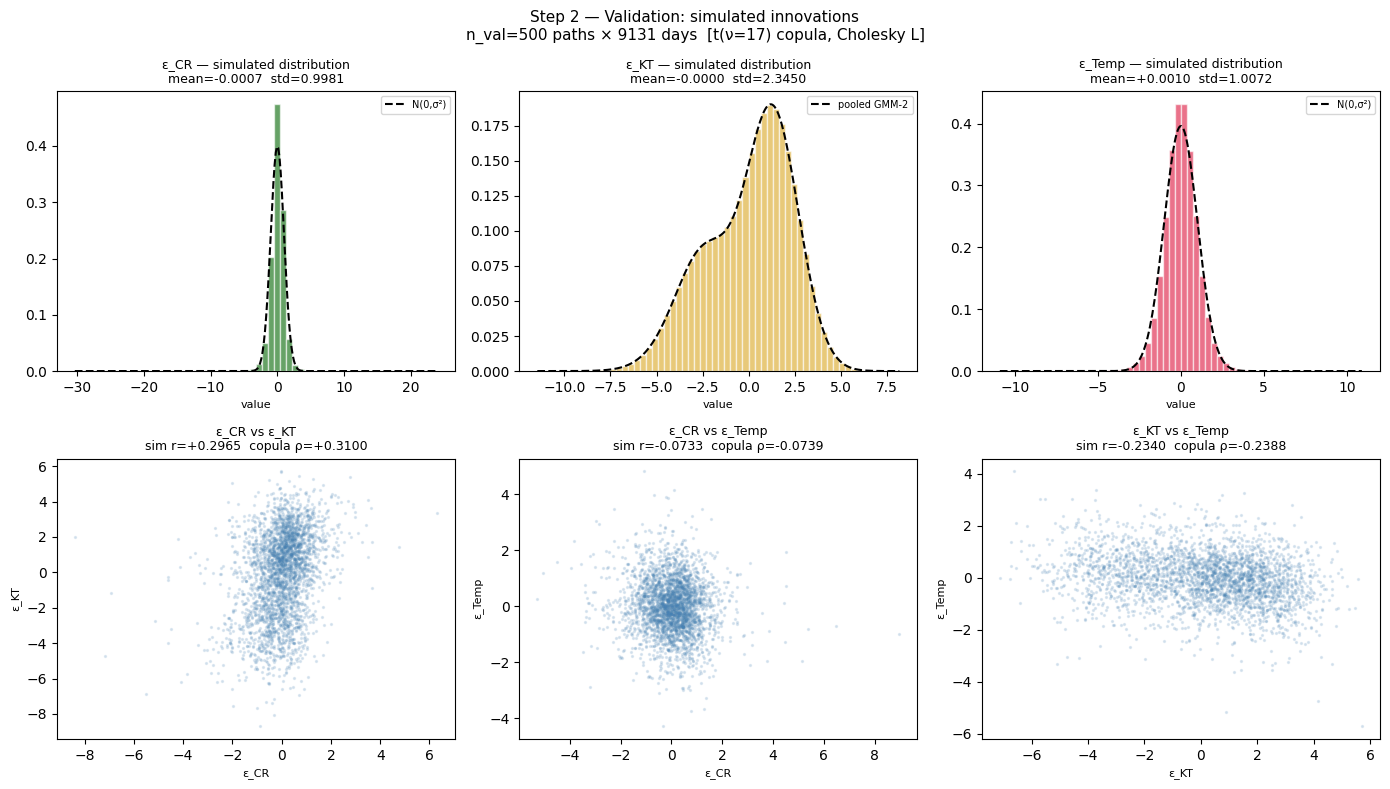

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Compare simulated marginal distributions and pairwise correlations
# against the historical values from the covariance notebook.
# Validation runs on a random sample of paths to avoid memory issues.
#
# These checks ASSERT rather than merely print.  A silent diagnostic table
# would allow a de-standardised eps_cr (std 1.377 against a target of 1.000)
# to propagate all the way into the published revenue index -- see D1.
 
print(f"\n── Step 2: Validation ───────────────────────────────────────────")
 
# ── 2A: marginal statistics ───────────────────────────────────────────────────
# sample 500 paths for validation
n_val    = min(500, N_SIM)
idx_val  = rng.choice(N_SIM, n_val, replace=False)
eps_cr_v = eps_cr_all[idx_val].ravel()
eps_kt_v = eps_kt_all[idx_val].ravel()
eps_tp_v = eps_temp_all[idx_val].ravel()
 
# target marginals
#   eps_cr   : unit variance — consumed as GARCH z_t downstream
#   eps_kt   : monthly Gaussian mixture — targets are the POOLED moments from
#              Step 0.3, not sigma_kt. The mixture is bimodal, so its excess
#              kurtosis is NEGATIVE (platykurtic); a 0.0 target here would
#              invite someone to "fix" a non-problem.
#   eps_temp : t(nu_temp) rescaled so std matches sigma_temp
hist_ref = {
    "eps_cr":   {"mean": 0.0, "std": 1.0,        "kurt_approx": 6/(nu_g-4) if nu_g>4 else 99, "dist": f"skewed-t(nu={nu_g:.1f}, eta={eta_g:+.4f})"},
    "eps_kt":   {"mean": mu_kt_pool, "std": std_kt_pool, "kurt_approx": -0.345},
    "eps_temp": {"mean": 0.0, "std": sigma_temp, "kurt_approx": 0.0},
}
 
# Relative tolerance on simulated vs target std. At n_val x N_DAYS ~ 4.6M draws
# the sampling SE of the std is 3e-04 relative, so the previous 0.02 was a 66-sigma
# band that could not fail. 0.005 is still a 16-sigma margin but actually bites.
# NOTE: the targets above must be set correctly regardless — a stale sigma_kt
# target is only 0.36% off and would slip through even at this tolerance.
STD_TOL = 0.005
 
print(f"\n  Marginal statistics (simulated vs target):")
print(f"  {'Variable':<12}  {'sim mean':>10}  {'tgt mean':>10}  "
      f"{'sim std':>9}  {'tgt std':>9}  {'rel err':>9}  {'sim kurt':>9}")
print(f"  {'-'*12}  {'-'*10}  {'-'*10}  "
      f"{'-'*9}  {'-'*9}  {'-'*9}  {'-'*9}")
 
std_failures = []
for label, col, vals in [
    ("eps_cr",   "eps_cr",   eps_cr_v),
    ("eps_kt",   "eps_kt",   eps_kt_v),
    ("eps_temp", "eps_temp", eps_tp_v),
]:
    ref     = hist_ref[col]
    rel_err = vals.std() / ref["std"] - 1.0
    flag    = "✓" if abs(rel_err) <= STD_TOL else "✗"
    print(f"  {label:<12}  "
          f"{vals.mean():>10.5f}  {ref['mean']:>10.5f}  "
          f"{vals.std():>9.5f}  {ref['std']:>9.5f}  "
          f"{rel_err:>+8.2%} {flag}  {stats.kurtosis(vals):>9.3f}")
    if abs(rel_err) > STD_TOL:
        std_failures.append(f"{label}: sim std {vals.std():.5f} vs target "
                            f"{ref['std']:.5f} ({rel_err:+.2%})")
 
if std_failures:
    raise ValueError(
        "STOP — simulated marginal scale does not match target:\n    "
        + "\n    ".join(std_failures)
        + "\n  Check the scale_* parameters in the marginal setup cell."
    )
print(f"\n  All marginal scales within ±{STD_TOL:.1%} of target ✓")
 
# ── 2A-bis: GARCH stationarity of the CR innovations ─────────────────────────
# The reconstruction notebooks feed eps_cr into
#     sigma2_t = omega + alpha·u²_{t-1} + beta·sigma2_{t-1},  u_t = eps_cr·sqrt(sigma2_t)
# whose variance recursion is stationary only if  alpha·E[z²] + beta < 1.
# This is the earliest point at which a mis-scaled eps_cr can be caught.
alpha_g_chk = float(cr_params["garch_alpha"])
beta_g_chk  = float(cr_params["garch_beta"])
ez2_cr      = float((eps_cr_v ** 2).mean())
persistence = alpha_g_chk * ez2_cr + beta_g_chk
 
print(f"\n  GARCH stationarity check (CR):")
print(f"    E[z²]                  = {ez2_cr:.5f}   (must be ≈ 1)")
print(f"    α·E[z²] + β            = {persistence:.5f}   (must be < 1)")
print(f"    implied uncond. σ      = "
      f"{np.sqrt((float(cr_params['garch_omega'])/1e4)/(1-persistence)):.5f}")
assert persistence < 1.0, (
    f"STOP — GARCH variance recursion is non-stationary: "
    f"α·E[z²] + β = {persistence:.5f} ≥ 1. "
    f"eps_cr must be unit-variance (E[z²] = 1); measured {ez2_cr:.5f}."
)
print(f"    stationary ✓")
 
# ── 2B: dependence structure ──────────────────────────────────────────────────
# Gate on KENDALL'S TAU, not Pearson r. The copula's rho parametrises the latent
# t-scores; the stored innovations are those scores pushed through three
# different marginal inversions, and Pearson r is not invariant to that. Tau is:
# for any elliptical copula, tau = (2/pi)*arcsin(rho) exactly, whatever the
# marginals. Pearson r is still printed, because a large sim-vs-copula gap there
# is informative about marginal asymmetry even though it is not an error.
#
# Tau is O(n log n), so it runs on a 200k subsample; its sampling SE at that size
# is about 0.0015, well inside the 0.02 tolerance below.
sim_mat  = np.column_stack([eps_cr_v, eps_kt_v, eps_tp_v])
corr_sim = np.corrcoef(sim_mat.T)

TAU_TOL  = 0.02
n_tau    = min(200_000, sim_mat.shape[0])
idx_tau  = rng.choice(sim_mat.shape[0], n_tau, replace=False)

print(f"\n  Dependence structure (n_tau={n_tau:,} subsample):")
print(f"  {'Pair':<12}  {'tau sim':>9}  {'tau tgt':>9}  {'delta':>8}  "
      f"{'r sim':>8}  {'r copula':>9}")
print(f"  {'-'*12}  {'-'*9}  {'-'*9}  {'-'*8}  {'-'*8}  {'-'*9}")

pair_labels = ["CR-KT", "CR-Temp", "KT-Temp"]
pair_idx    = [(0, 1),  (0, 2),    (1, 2)]
tau_failures = []
for label, (i, j) in zip(pair_labels, pair_idx):
    rho_cop = float(corr_matrix[i, j])
    tau_tgt = 2.0 / np.pi * np.arcsin(rho_cop)
    tau_sim = float(stats.kendalltau(sim_mat[idx_tau, i],
                                     sim_mat[idx_tau, j])[0])
    d       = tau_sim - tau_tgt
    flag    = "OK" if abs(d) <= TAU_TOL else "FAIL"
    print(f"  {label:<12}  {tau_sim:>9.4f}  {tau_tgt:>9.4f}  {d:>+8.4f}  "
          f"{corr_sim[i, j]:>8.4f}  {rho_cop:>9.4f}  {flag}")
    if abs(d) > TAU_TOL:
        tau_failures.append(
            f"{label}: tau {tau_sim:+.4f} vs target {tau_tgt:+.4f} ({d:+.4f})")

if tau_failures:
    raise ValueError(
        "STOP - simulated dependence does not match the fitted copula:\n    "
        + "\n    ".join(tau_failures)
        + "\n  The Cholesky factor or the copula draw is wrong; re-check "
          "06_copula.ipynb and the chol_matrix reconstruction above."
    )
print(f"  All pairwise tau within +/-{TAU_TOL:.3f} of the copula target")
 
# ── 2C: PIT uniformity check on sample ────────────────────────────────────────
# Each variable is inverted through ITS OWN marginal CDF — CR is skewed-t, so
# the symmetric t CDF would not return uniforms even when the draw is correct.
print(f"\n  PIT uniformity check (KS test vs Uniform[0,1]):")
print(f"  {'Variable':<12}  {'U mean':>8}  {'U std':>8}  {'KS stat':>8}  "
      f"{'KS p':>10}  result")
print(f"  {'-'*12}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*10}  ------")
 
# eps_kt_v is eps_kt_all[idx_val].ravel(), i.e. C-order path-major/day-minor,
# so the month vector must be TILED (one full calendar per sampled path), not
# repeated. Getting this backwards silently returns KS p ~ 1e-299.
mon_val = np.tile(df_calendar["month"].to_numpy(), n_val)
 
pit_specs = [
    ("eps_cr",   eps_cr_v,  lambda v: _skewt.cdf(v / scale_unit_cr, _skewt_parm)),
    ("eps_kt",   eps_kt_v,  lambda v: mix_cdf(v, mon_val, kt_mix)),
    ("eps_temp", eps_tp_v,  lambda v: t_dist.cdf(v / scale_temp, df=nu_temp)),
]
# D6: the gate is on the KS STATISTIC, not its p-value. At n ~ 4.6M a KS test
# rejects on departures far smaller than the 1e-7 grid-interpolation error of
# the KT inverse, so a p-value gate would fail on a perfectly correct run. The
# statistic's own sampling noise at this n is about 4e-4, so 1e-2 leaves a wide
# margin while still catching the failure this check exists for: a mis-tiled
# month vector, which drives the statistic to roughly 0.3.
KS_TOL      = 0.01
pit_failures = []
for label, vals, cdf_fn in pit_specs:
    U = np.clip(cdf_fn(vals), 1e-6, 1-1e-6)
    ks_stat, ks_p = stats.kstest(U, "uniform")
    flag = "OK" if ks_stat <= KS_TOL else "FAIL"
    print(f"  {label:<12}  {U.mean():>8.4f}  {U.std():>8.4f}  "
          f"{ks_stat:>8.5f}  {ks_p:>10.3e}  {flag}")
    if ks_stat > KS_TOL:
        pit_failures.append(
            f"{label}: KS statistic {ks_stat:.5f} exceeds {KS_TOL}")

if pit_failures:
    raise ValueError(
        "STOP - PIT transform does not return uniforms:\n    "
        + "\n    ".join(pit_failures)
        + "\n  Each variable must be inverted through ITS OWN marginal CDF, "
          "and the KT month vector must be TILED (one full calendar per "
          "sampled path), not repeated."
    )
print(f"  All PIT transforms uniform to within KS <= {KS_TOL}")
 
# ── 2D: validation plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
 
# row 1: marginal distributions
# The KT reference is the POOLED mixture density (each month's mixture weighted
# by its share of the calendar), not a Gaussian — the simulated histogram is
# bimodal and a normal curve through it would look like a failure when it is not.
def _kt_pool_pdf(x):
    x   = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    for m in range(1, 13):
        mp = kt_mix[m]
        out += _p_month[m - 1] * (
            mp["weights"][0] * norm.pdf(x, mp["means"][0], mp["stds"][0]) +
            mp["weights"][1] * norm.pdf(x, mp["means"][1], mp["stds"][1]))
    return out
 
for j, (label, vals, color, ref_pdf, ref_lbl) in enumerate([
    ("ε_CR",   eps_cr_v, "darkgreen",
     lambda x: stats.norm.pdf(x, 0, eps_cr_v.std()), "N(0,σ²)"),
    ("ε_KT",   eps_kt_v, "goldenrod", _kt_pool_pdf, "pooled GMM-2"),
    ("ε_Temp", eps_tp_v, "crimson",
     lambda x: stats.norm.pdf(x, 0, eps_tp_v.std()), "N(0,σ²)"),
]):
    ax = axes[0, j]
    ax.hist(vals, bins=60, density=True, color=color,
            alpha=0.6, edgecolor="white")
    x_g = np.linspace(vals.min(), vals.max(), 300)
    ax.plot(x_g, ref_pdf(x_g),
            color="black", lw=1.5, ls="--", label=ref_lbl)
    ax.set_title(f"{label} — simulated distribution\n"
                 f"mean={vals.mean():+.4f}  std={vals.std():.4f}",
                 fontsize=9)
    ax.set_xlabel("value", fontsize=8)
    ax.legend(fontsize=7)
 
# row 2: scatter plots of key pairs
pair_plot = [
    ("ε_CR",   eps_cr_v, "ε_KT",   eps_kt_v, corr_matrix[0,1]),
    ("ε_CR",   eps_cr_v, "ε_Temp", eps_tp_v, corr_matrix[0,2]),
    ("ε_KT",   eps_kt_v, "ε_Temp", eps_tp_v, corr_matrix[1,2]),
]
for j, (xl, xv, yl, yv, rho_cop) in enumerate(pair_plot):
    ax = axes[1, j]
    # subsample for plot
    idx_p = rng.choice(len(xv), min(3000, len(xv)), replace=False)
    ax.scatter(xv[idx_p], yv[idx_p], s=2, alpha=0.15, color="steelblue")
    r_s = np.corrcoef(xv, yv)[0, 1]
    ax.set_xlabel(xl, fontsize=8)
    ax.set_ylabel(yl, fontsize=8)
    ax.set_title(f"{xl} vs {yl}\n"
                 f"sim r={r_s:+.4f}  copula ρ={rho_cop:+.4f}",
                 fontsize=9)
 
plt.suptitle(f"Step 2 — Validation: simulated innovations\n"
             f"n_val={n_val} paths × {N_DAYS} days  "
             f"[t(ν={nu_copula}) copula, Cholesky L]",
             fontsize=11)
plt.tight_layout()
plt.show()

> **Takeaway.** The three marginals reproduce their target scale to within half
> a percent, the pairwise Kendall tau match the fitted copula, and each PIT
> transform returns uniforms. The GARCH stationarity check is the one that
> matters most downstream: it is the earliest point at which a mis-scaled
> capture-rate innovation can be caught, and the only one before the error would
> reach the published revenue index.

## Export

In [11]:
# STEP 3 — Save to parquet
# ─────────────────────────────────────────────────────────────────────────────
# Long format: one row per (sim_id, date)
# Columns: sim_id, date, eps_cr, eps_kt, eps_temp
#
# Memory note: N_SIM × N_DAYS rows in long format can be large.
# We write in chunks by sim_id to avoid peak memory issues.
 
print(f"\n── Step 3: Save innovations ─────────────────────────────────────")
 
out_path   = data_sim / "mc_innovations.parquet"
CHUNK_SIZE = 500   # sim paths per write chunk
 
print(f"  Output path : {out_path}")
print(f"  Format      : long  (sim_id, date, eps_cr, eps_kt, eps_temp)")
print(f"  Writing {N_SIM} paths in chunks of {CHUNK_SIZE}...")
 
t_save = time.time()
# Chunks stream straight to disk as parquet row groups, so peak memory is one
# chunk rather than the whole frame. The row-group structure also
# lets the reconstruction notebook read one column for the first K paths without
# touching the rest of the file -- the reconstruction
# notebook reads row groups directly for exactly this reason.

writer    = None
n_rows    = 0
col_names = None
 
for chunk_start in range(0, N_SIM, CHUNK_SIZE):
    chunk_end = min(chunk_start + CHUNK_SIZE, N_SIM)
    n_chunk   = chunk_end - chunk_start
 
    # tile dates for this chunk: (n_chunk × N_DAYS,)
    dates_rep = np.tile(dates_sim, n_chunk)
    sim_ids   = np.repeat(np.arange(chunk_start, chunk_end), N_DAYS)
 
    chunk_df = pd.DataFrame({
        "sim_id":   sim_ids.astype(np.int32),
        "date":     dates_rep,
        "eps_cr":   eps_cr_all[chunk_start:chunk_end].ravel(),
        "eps_kt":   eps_kt_all[chunk_start:chunk_end].ravel(),
        "eps_temp": eps_temp_all[chunk_start:chunk_end].ravel(),
    })
    table = pa.Table.from_pandas(chunk_df, preserve_index=False)
    if writer is None:
        writer    = pq.ParquetWriter(out_path, table.schema, compression="snappy")
        col_names = list(chunk_df.columns)
    writer.write_table(table)
    n_rows += len(chunk_df)
    del chunk_df, table
 
print(f"  Finalising parquet...")
if writer is not None:
    writer.close()
 

t_saved = time.time() - t_save
 
file_mb = out_path.stat().st_size / 1e6
print(f"  Saved in {t_saved:.1f}s")
print(f"  File size: {file_mb:.1f} MB")
print(f"  Rows     : {n_rows:,}")
print(f"  Columns  : {col_names}")


── Step 3: Save innovations ─────────────────────────────────────
  Output path : C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Data\Simulated\mc_innovations.parquet
  Format      : long  (sim_id, date, eps_cr, eps_kt, eps_temp)
  Writing 5000 paths in chunks of 500...


  Finalising parquet...
  Saved in 18.9s
  File size: 716.9 MB
  Rows     : 45,655,000
  Columns  : ['sim_id', 'date', 'eps_cr', 'eps_kt', 'eps_temp']


In [12]:
# ── save simulation metadata ──────────────────────────────────────────────────
sim_metadata = {
    "random_seed":    RANDOM_SEED,
    "N_SIM":          N_SIM,
    "N_DAYS":         N_DAYS,
    "start_date":     START_DATE,
    "end_date":       END_DATE,
    "variable_cols":  VAR_COLS,
    "variable_labels":VAR_LABELS,
    "copula_type":    copula_params["copula_type"],
    "nu_copula":      nu_copula,
    "nu_g":           nu_g,
    "eta_g":          eta_g,
    "scale_unit_cr":  scale_unit_cr,
    "kt_marginal":    {"type": "gmm_monthly",
                       "n_components": 2,
                       "params": kt_mix,
                       "pooled_mean": mu_kt_pool,
                       "pooled_std":  std_kt_pool},
    "sigma_kt":       sigma_kt,   # legacy Gaussian sd — NOT the margin used
    "nu_temp":        nu_temp,     
    "scale_temp":     scale_temp,
    "sigma_temp":     sigma_temp,
    "corr_matrix":    corr_matrix.tolist(),
    "chol_matrix":    chol_matrix.tolist(),
    "output_file":    str(out_path),
    "file_size_mb":   round(file_mb, 2),
}
 
with open(data_sim / "mc_innovations_metadata.pkl", "wb") as f:
    pickle.dump(sim_metadata, f)
 
print(f"  Metadata saved: {data_sim / 'mc_innovations_metadata.pkl'}")

  Metadata saved: C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Data\Simulated\mc_innovations_metadata.pkl


## Conclusion & Handoff

- `N_SIM` x `N_DAYS` correlated innovations drawn from the fitted t-copula, each
  variable inverted through its own marginal: skewed-t for the capture rate (D1),
  a per-month 2-component Gaussian mixture for clearness (D2, D3), and a scaled
  Student-t for temperature.
- Marginal scale, GARCH stationarity, dependence structure and PIT uniformity
  are all gated (D6), so a mis-scaled innovation stops here rather than
  surfacing as a wrong revenue index.

**Next notebook can rely on:** `Data/Simulated/mc_innovations.parquet` — long
format `(sim_id, date, eps_cr, eps_kt, eps_temp)`, sim-major, float32, written
in row groups of 500 paths. `Data/Simulated/mc_innovations_metadata.pkl` carries
the seed, the marginal parameters and the copula matrices used.

These innovations are scenario-agnostic and are read unchanged by
`02_variables_reconstruction.ipynb` for every penetration scenario, which is
what makes the scenario comparison a common-random-numbers experiment.